# Load Data

In [12]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import glob
import numpy as np

files = glob.glob('/content/drive/MyDrive/AceIQ/data/atp_matches_*.csv')
df = pd.concat([pd.read_csv(f, low_memory=False) for f in sorted(files)])

print(f"Shape: {df.shape}")
for f in sorted(files):
    tmp = pd.read_csv(f, low_memory=False)
    print(f"{f} — {len(tmp)} rows")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (115104, 49)
/content/drive/MyDrive/AceIQ/data/atp_matches_2015.csv — 2943 rows
/content/drive/MyDrive/AceIQ/data/atp_matches_2016.csv — 2941 rows
/content/drive/MyDrive/AceIQ/data/atp_matches_2017.csv — 2911 rows
/content/drive/MyDrive/AceIQ/data/atp_matches_2018.csv — 2897 rows
/content/drive/MyDrive/AceIQ/data/atp_matches_2019.csv — 2806 rows
/content/drive/MyDrive/AceIQ/data/atp_matches_2020.csv — 1462 rows
/content/drive/MyDrive/AceIQ/data/atp_matches_2021.csv — 2733 rows
/content/drive/MyDrive/AceIQ/data/atp_matches_2022.csv — 2917 rows
/content/drive/MyDrive/AceIQ/data/atp_matches_2023.csv — 2986 rows
/content/drive/MyDrive/AceIQ/data/atp_matches_2024.csv — 3076 rows
/content/drive/MyDrive/AceIQ/data/atp_matches_qual_chall_2015.csv — 6898 rows
/content/drive/MyDrive/AceIQ/data/atp_matches_qual_chall_2016.csv — 9849 rows
/content/drive/MyDrive/Ac

# EDA

Missing values:
surface                  53
winner_seed           62489
winner_entry          97057
winner_ht              4898
winner_age               11
loser_seed            83740
loser_entry           84544
loser_hand               11
loser_ht               9943
loser_ioc                 1
loser_age               106
score                    15
minutes                9995
w_ace                  3829
w_df                   3829
w_svpt                 3829
w_1stIn                3829
w_1stWon               3829
w_2ndWon               3829
w_SvGms                3831
w_bpSaved              3829
w_bpFaced              3829
l_ace                  3829
l_df                   3829
l_svpt                 3829
l_1stIn                3829
l_1stWon               3829
l_2ndWon               3829
l_SvGms                3831
l_bpSaved              3829
l_bpFaced              3829
winner_rank             956
winner_rank_points      970
loser_rank             3816
loser_rank_points      3831
dtyp

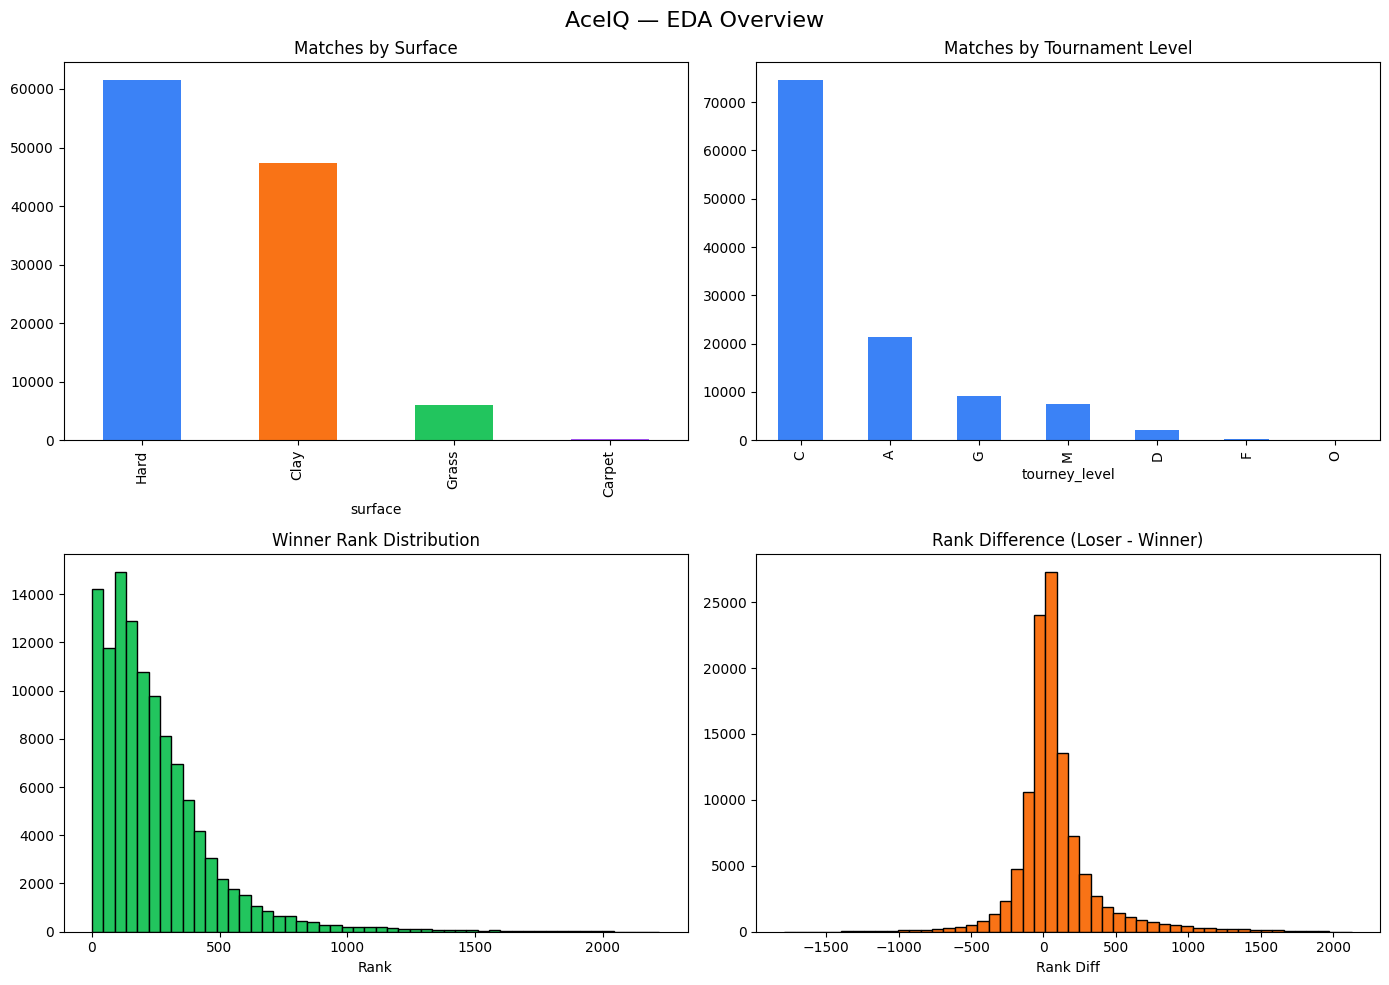

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check missing values
print("Missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Favorite win rate
df['favorite_won'] = (df['winner_rank'] < df['loser_rank']).astype(int)
print(f"\nFavorite win rate: {df['favorite_won'].mean()*100:.1f}%")
print("\nBy surface:")
print(df.groupby('surface')['favorite_won'].mean().sort_values(ascending=False))
print("\nBy tourney level:")
print(df.groupby('tourney_level')['favorite_won'].mean().sort_values(ascending=False))

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('AceIQ — EDA Overview', fontsize=16)

df['surface'].value_counts().plot(kind='bar', ax=axes[0,0], color=['#3b82f6','#f97316','#22c55e','#a855f7'])
axes[0,0].set_title('Matches by Surface')

df['tourney_level'].value_counts().plot(kind='bar', ax=axes[0,1], color='#3b82f6')
axes[0,1].set_title('Matches by Tournament Level')

axes[1,0].hist(df['winner_rank'].dropna(), bins=50, color='#22c55e', edgecolor='black')
axes[1,0].set_title('Winner Rank Distribution')
axes[1,0].set_xlabel('Rank')

df['rank_diff'] = df['loser_rank'] - df['winner_rank']
axes[1,1].hist(df['rank_diff'].dropna(), bins=50, color='#f97316', edgecolor='black')
axes[1,1].set_title('Rank Difference (Loser - Winner)')
axes[1,1].set_xlabel('Rank Diff')

plt.tight_layout()
plt.show()

## EDA Conclusions

**Dataset:** 25,169 ATP matches (2015-2024)

**Surface distribution:**
- Hard: 58% of matches — dominant surface
- Clay: 30% — enough data
- Grass: 11% — limited, consider separate model later
- Carpet: removed — obsolete surface

**Tournament levels:**
- Removed: Davis Cup (D), Olympics (O), Futures (F) — different format/motivation
- Kept: Grand Slam (G), Masters (M), ATP (A)

**Key insight — favorite win rate:**
- Overall: 63.6% — baseline for our model to beat
- Grand Slam: 71% — favorites dominate (high motivation, top players prepared)
- Masters: 65%
- ATP 250: 62% — more upsets (top players less motivated)
- Carpet: 47% — basically a coin flip, removed

**Target for model accuracy: 72-78%**

# Clean data

In [14]:
# Remove carpet and irrelevant tournament levels
df = df[df['surface'] != 'Carpet']
df = df[~df['tourney_level'].isin(['D', 'O', 'F'])]

# Drop rows without critical features
df = df.dropna(subset=['winner_rank', 'loser_rank', 'surface'])

# Sort by date
df['tourney_date'] = pd.to_datetime(df['tourney_date'].astype(str), format='%Y%m%d')
df = df.sort_values('tourney_date').reset_index(drop=True)

print(f"Clean dataset shape: {df.shape}")
print(f"Years covered: {df['tourney_date'].dt.year.unique()}")

Clean dataset shape: (108342, 51)
Years covered: [2015 2016 2017 2018 2019 2020 2021 2022 2023 2024]


# Feature engineering:

In [15]:
from sklearn.preprocessing import OneHotEncoder

# One-Hot Encoding for surface
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
surface_encoded = ohe.fit_transform(df[['surface']])
surface_cols = ohe.get_feature_names_out(['surface'])
surface_df = pd.DataFrame(surface_encoded, columns=surface_cols, index=df.index)
df = pd.concat([df, surface_df], axis=1)

# Tournament level — ordinal encoding (order is real: G > M > A)
level_map = {'G': 4, 'M': 3, 'A': 2, 'C': 1}
df['level_enc'] = df['tourney_level'].map(level_map).fillna(0)

# Rank features
df['rank_diff'] = df['loser_rank'] - df['winner_rank']
df['rank_ratio'] = df['loser_rank'] / df['winner_rank'].replace(0, 1)

print("Features created:")
print(df[list(surface_cols) + ['level_enc', 'rank_diff', 'rank_ratio']].describe())

Features created:
        surface_Clay  surface_Grass   surface_Hard      level_enc  \
count  108342.000000  108342.000000  108342.000000  108342.000000   
mean        0.415213       0.053950       0.530838       1.586753   
std         0.492761       0.225919       0.499050       0.942491   
min         0.000000       0.000000       0.000000       1.000000   
25%         0.000000       0.000000       0.000000       1.000000   
50%         0.000000       0.000000       1.000000       1.000000   
75%         1.000000       0.000000       1.000000       2.000000   
max         1.000000       1.000000       1.000000       4.000000   

           rank_diff     rank_ratio  
count  108342.000000  108342.000000  
mean       77.371518       2.402545  
std       285.369706       7.140460  
min     -1787.000000       0.005714  
25%       -42.000000       0.768461  
50%        35.000000       1.282486  
75%       141.000000       2.174577  
max      2126.000000     542.000000  


# Form features

In [8]:
def calculate_form(df, n=10):
    # Track win/loss history per player {player_id: [1, 0, 1, ...]}
    player_history = {}
    winner_form = []
    loser_form = []

    for _, row in df.iterrows():
        w_id = row['winner_id']
        l_id = row['loser_id']

        # Get player history
        w_history = player_history.get(w_id, [])
        l_history = player_history.get(l_id, [])

        # Calculate form — average of last n matches
        w_form = sum(w_history[-n:]) / n if len(w_history) >= n else sum(w_history) / max(len(w_history), 1)
        l_form = sum(l_history[-n:]) / n if len(l_history) >= n else sum(l_history) / max(len(l_history), 1)

        winner_form.append(w_form)
        loser_form.append(l_form)

        # Update history AFTER recording (no data leakage)
        player_history.setdefault(w_id, []).append(1)
        player_history.setdefault(l_id, []).append(0)

    df['winner_form'] = winner_form
    df['loser_form'] = loser_form
    df['form_diff'] = df['winner_form'] - df['loser_form']
    return df


def calculate_surface_winrate(df):
    # Track wins and total matches per player per surface
    player_surface = {}  # {(player_id, surface): [wins, total]}
    winner_surface_wr = []
    loser_surface_wr = []

    for _, row in df.iterrows():
        w_id = row['winner_id']
        l_id = row['loser_id']
        surface = row['surface']

        w_key = (w_id, surface)
        l_key = (l_id, surface)

        # Get current stats
        w_stats = player_surface.get(w_key, [0, 0])
        l_stats = player_surface.get(l_key, [0, 0])

        # Calculate win rate (default 0.5 if no history)
        w_wr = w_stats[0] / w_stats[1] if w_stats[1] > 0 else 0.5
        l_wr = l_stats[0] / l_stats[1] if l_stats[1] > 0 else 0.5

        winner_surface_wr.append(w_wr)
        loser_surface_wr.append(l_wr)

        # Update AFTER recording (no data leakage)
        player_surface[w_key] = [w_stats[0] + 1, w_stats[1] + 1]
        player_surface[l_key] = [l_stats[0], l_stats[1] + 1]

    df['winner_surface_wr'] = winner_surface_wr
    df['loser_surface_wr'] = loser_surface_wr
    df['surface_wr_diff'] = df['winner_surface_wr'] - df['loser_surface_wr']
    return df


df = calculate_form(df, n=10)
df = calculate_surface_winrate(df)
print(df[['winner_form', 'loser_form', 'form_diff',
          'winner_surface_wr', 'loser_surface_wr', 'surface_wr_diff']].describe())

In [16]:
def calculate_surface_winrate(df):
    # Track wins and matches per player per surface
    player_surface = {}  # {(player_id, surface): [wins, total]}

    winner_surface_wr = []
    loser_surface_wr = []

    for _, row in df.iterrows():
        w_id = row['winner_id']
        l_id = row['loser_id']
        surface = row['surface']

        w_key = (w_id, surface)
        l_key = (l_id, surface)

        # Get current stats
        w_stats = player_surface.get(w_key, [0, 0])
        l_stats = player_surface.get(l_key, [0, 0])

        # Calculate win rate
        w_wr = w_stats[0] / w_stats[1] if w_stats[1] > 0 else 0.5
        l_wr = l_stats[0] / l_stats[1] if l_stats[1] > 0 else 0.5

        winner_surface_wr.append(w_wr)
        loser_surface_wr.append(l_wr)

        # Update AFTER recording (no data leakage)
        player_surface[w_key] = [w_stats[0] + 1, w_stats[1] + 1]
        player_surface[l_key] = [l_stats[0], l_stats[1] + 1]

    df['winner_surface_wr'] = winner_surface_wr
    df['loser_surface_wr'] = loser_surface_wr
    df['surface_wr_diff'] = df['winner_surface_wr'] - df['loser_surface_wr']

    return df

df = calculate_surface_winrate(df)
print(df[['winner_surface_wr', 'loser_surface_wr', 'surface_wr_diff']].describe())

       winner_surface_wr  loser_surface_wr  surface_wr_diff
count      108342.000000     108342.000000    108342.000000
mean            0.516409          0.484281         0.032128
std             0.144280          0.159265         0.189142
min             0.000000          0.000000        -1.000000
25%             0.459770          0.428571        -0.061376
50%             0.534483          0.500000         0.026171
75%             0.597884          0.574297         0.122953
max             1.000000          1.000000         1.000000


## Feature Engineering Conclusions

**Features created so far:**

| Feature | Description | Importance |
|---|---|---|
| surface_Hard/Clay/Grass | One-Hot encoded surface | High |
| level_enc | Tournament prestige (1-4) | Medium |
| rank_diff | Rank difference (loser - winner) | Very High |
| rank_ratio | Rank ratio | High |
| winner/loser_form | Win rate last 10 matches | High |
| form_diff | Form difference | High |
| winner/loser_surface_wr | Win rate on this surface | Very High |
| surface_wr_diff | Surface win rate difference | High |


# H2H features

In [17]:
def h2h_calculate(df):
  history = {}

  winner_wins = []
  loser_wins = []
  for _, row in df.iterrows():
    w_id = row['winner_id']
    l_id = row['loser_id']

    # Key: sorted pair so A vs B == B vs A
    key = (min(w_id, l_id), max(w_id, l_id))

    # Get current h2h stats {key: [w_id_wins, l_id_wins]}
    stats = history.get(key, {w_id: 0, l_id: 0})

    # Record BEFORE updating
    winner_wins.append(stats.get(w_id, 0))
    loser_wins.append(stats.get(l_id, 0))

    # Update AFTER recording
    stats[w_id] = stats.get(w_id, 0) + 1
    history[key] = stats

  df['h2h_winner_wins'] = winner_wins
  df['h2h_loser_wins'] = loser_wins
  df['h2h_diff'] = df['h2h_winner_wins'] - df['h2h_loser_wins']
  return df

df = h2h_calculate(df)
print(df[['h2h_winner_wins', 'h2h_loser_wins', 'h2h_diff']].describe())

       h2h_winner_wins  h2h_loser_wins       h2h_diff
count    108342.000000   108342.000000  108342.000000
mean          0.264090        0.212651       0.051439
std           0.670438        0.578102       0.748032
min           0.000000        0.000000     -10.000000
25%           0.000000        0.000000       0.000000
50%           0.000000        0.000000       0.000000
75%           0.000000        0.000000       0.000000
max          13.000000       11.000000      13.000000


## H2H Feature Conclusions

**Key observations:**
- 75% of matches have h2h_diff = 0 — first-time meetings dominate ATP tour
- H2H is most relevant for top players who meet regularly (Djokovic, Nadal, Federer)
- Max 13 wins in h2h — long rivalries like Djokovic vs Nadal
- Mean h2h_diff = 0.05 — small but consistent advantage for historical winner

**Important:** H2H feature will have low importance for most matches
but high importance for top-100 player predictions — model will learn this automatically

In [20]:
df = calculate_form(df, n=10)
print(df[['winner_form', 'loser_form', 'form_diff']].head())

   winner_form  loser_form  form_diff
0          0.0         0.0        0.0
1          0.0         0.0        0.0
2          0.0         0.0        0.0
3          0.0         0.0        0.0
4          0.0         0.0        0.0


In [21]:
rows = []

for _, row in df.iterrows():
    # Match from winner's perspective — target = 1
    rows.append({
        'surface_Clay': row['surface_Clay'],
        'surface_Grass': row['surface_Grass'],
        'surface_Hard': row['surface_Hard'],
        'level_enc': row['level_enc'],
        'p1_rank': row['winner_rank'],
        'p2_rank': row['loser_rank'],
        'rank_diff': row['rank_diff'],
        'rank_ratio': row['rank_ratio'],
        'p1_form': row['winner_form'],
        'p2_form': row['loser_form'],
        'form_diff': row['form_diff'],
        'p1_surface_wr': row['winner_surface_wr'],
        'p2_surface_wr': row['loser_surface_wr'],
        'surface_wr_diff': row['surface_wr_diff'],
        'p1_h2h_wins': row['h2h_winner_wins'],
        'p2_h2h_wins': row['h2h_loser_wins'],
        'h2h_diff': row['h2h_diff'],
        'target': 1
    })

    # Match from loser's perspective — target = 0
    rows.append({
        'surface_Clay': row['surface_Clay'],
        'surface_Grass': row['surface_Grass'],
        'surface_Hard': row['surface_Hard'],
        'level_enc': row['level_enc'],
        'p1_rank': row['loser_rank'],
        'p2_rank': row['winner_rank'],
        'rank_diff': -row['rank_diff'],
        'rank_ratio': 1 / row['rank_ratio'] if row['rank_ratio'] != 0 else 0,
        'p1_form': row['loser_form'],
        'p2_form': row['winner_form'],
        'form_diff': -row['form_diff'],
        'p1_surface_wr': row['loser_surface_wr'],
        'p2_surface_wr': row['winner_surface_wr'],
        'surface_wr_diff': -row['surface_wr_diff'],
        'p1_h2h_wins': row['h2h_loser_wins'],
        'p2_h2h_wins': row['h2h_winner_wins'],
        'h2h_diff': -row['h2h_diff'],
        'target': 0
    })

df_model = pd.DataFrame(rows)
df_model = df_model.dropna()

print(f"Final dataset shape: {df_model.shape}")
print(f"Target distribution:\n{df_model['target'].value_counts()}")

df_model.to_csv('/content/drive/MyDrive/AceIQ/data/model_dataset.csv', index=False)
print("\nSaved to Drive!")

Final dataset shape: (216684, 18)
Target distribution:
target
1    108342
0    108342
Name: count, dtype: int64

Saved to Drive!
